In [18]:
#!/bin/bash
!kaggle datasets download jackksoncsie/spam-email-dataset

Dataset URL: https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset
License(s): GNU Lesser General Public License 3.0
spam-email-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
!unzip /content/spam-email-dataset.zip

Archive:  /content/spam-email-dataset.zip
replace emails.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: emails.csv              


# Spam Email Classification

## 1. Imports

In [20]:
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## 2. Data Loading

In [21]:
df = pd.read_csv("/emails.csv")

In [22]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## 3. Exploratory Data Analysis (EDA)

In [23]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)

print(df.shape)

Dataset Shape
(5728, 2)


In [24]:
print("=" * 50)
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [25]:
print("=" * 50)
print("Missing Values")
print("=" * 50)

print(df.isnull().sum())

Missing Values
text    0
spam    0
dtype: int64


In [26]:
print("=" * 50)
print("Duplicate Values")
print("=" * 50)

print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

Duplicate Values
33


Target Distribution
spam
0    4327
1    1368
Name: count, dtype: int64


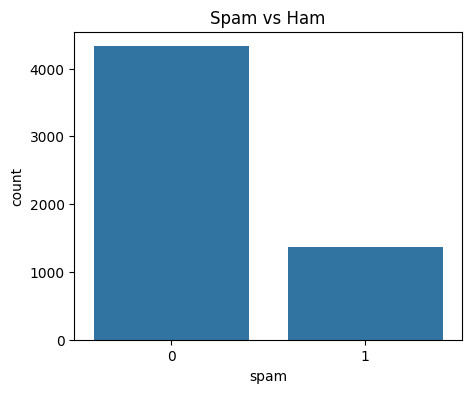

In [27]:
print("=" * 50)
print("Target Distribution")
print("=" * 50)

print(df["spam"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="spam")
plt.title("Spam vs Ham")
plt.show()

Message Length


,length
count,5695.000000
mean,1558.067076
std,2047.078711
min,13.000000
25%,508.500000
50%,979.000000
75%,1893.000000
max,43952.000000


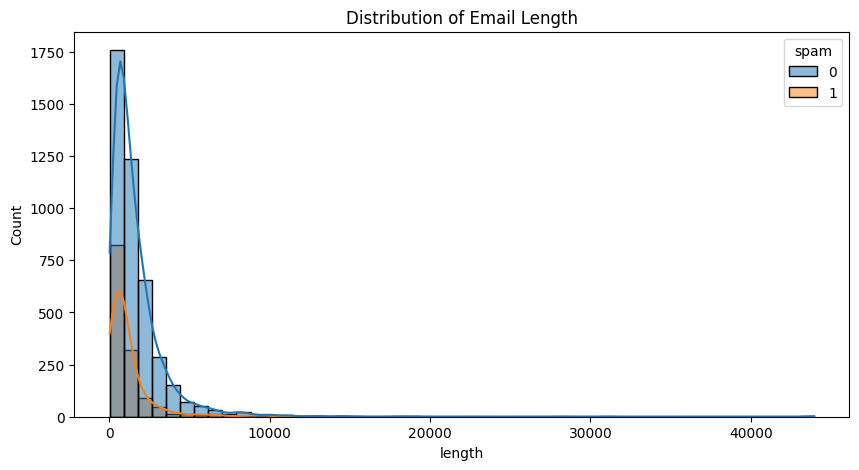

In [28]:
print("=" * 50)
print("Message Length")
print("=" * 50)

df["length"] = df["text"].str.len()

display(df["length"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="length",
    hue="spam",
    bins=50,
    kde=True
)
plt.title("Distribution of Email Length")
plt.show()

### 3.1 Most Common Words (Quick Look)

Simple processing (lowercase + punctuation removal) is used only to display the most frequently occurring words in each category before full processing.

In [29]:
def simple_preprocess(text):
    text = text.lower()
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    return text

df["simple_text"] = df["text"].apply(simple_preprocess)

spam_words = ' '.join(
    df[df["spam"] == 1]["simple_text"]
).split()

ham_words = ' '.join(
    df[df["spam"] == 0]["simple_text"]
).split()

spam_counter = Counter(spam_words)
ham_counter = Counter(ham_words)

spam_df = pd.DataFrame(
    spam_counter.most_common(20),
    columns=["Word", "Count"]
)

ham_df = pd.DataFrame(
    ham_counter.most_common(20),
    columns=["Word", "Count"]
)

print("Top Spam Words")
display(spam_df)

print("Top Ham Words")
display(ham_df)

Top Spam Words


,Word,Count
0,the,8975
1,to,8165
2,and,6517
3,of,5629
4,you,4920
5,a,4695
6,in,3879
7,your,3730
8,for,3186
9,is,2977


Top Ham Words


,Word,Count
0,the,40935
1,to,33369
2,and,20805
3,of,18027
4,i,15510
5,a,15153
6,you,14107
7,in,14015
8,for,13452
9,enron,13329


## 4. Text Preprocessing

Complete text processing: lowercase, removal of links, numbers and punctuation, removal of stopwords, and application of lemmatization.

In [30]:
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = []
    for word in text.split():
        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            words.append(word)

    return " ".join(words)

df["processed_text"] = df["text"].apply(preprocess)

display(df[["text", "processed_text"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,processed_text
0,Subject: naturally irresistible your corporate...,subject naturally irresistible corporate ident...
1,Subject: the stock trading gunslinger fanny i...,subject stock trading gunslinger fanny merrill...
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new home made easy im wan...
3,Subject: 4 color printing special request add...,subject color printing special request additio...
4,"Subject: do not have money , get software cds ...",subject money get software cd software compati...


## 5. Train / Test Split

In [31]:
X = df["processed_text"]
y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4556,)
(1139,)
(4556,)
(1139,)


### Text Vectorization

Now that the data is split, we need to convert the text into numerical features that a machine learning model can understand. We'll use TF-IDF (Term Frequency-Inverse Document Frequency) for this purpose. TF-IDF reflects how important a word is to a document in a collection or corpus.

### Model Training and Evaluation

Now, we'll build a machine learning pipeline that includes the TF-IDF vectorizer and a classifier for each model, train it, and evaluate its performance on the test set.

In [32]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(max_iter=1000)
}

In [33]:
yresults = []
pipelines = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1 Score": f1
    })

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

Naive Bayes
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       865
           1       1.00      0.57      0.73       274

    accuracy                           0.90      1139
   macro avg       0.94      0.78      0.83      1139
weighted avg       0.91      0.90      0.89      1139

[[865   0]
 [118 156]]
Logistic Regression
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       865
           1       0.99      0.93      0.96       274

    accuracy                           0.98      1139
   macro avg       0.99      0.97      0.98      1139
weighted avg       0.98      0.98      0.98      1139

[[863   2]
 [ 18 256]]
Linear SVM
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       865
           1       0.99      0.98      0.99       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      

In [34]:
results = pd.DataFrame(results)

results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.992976,0.992593,0.978102,0.985294
1,Logistic Regression,0.982441,0.992248,0.934307,0.962406
0,Naive Bayes,0.896400,1.000000,0.569343,0.725581


### Improving Linear SVM: Cross-Validation

Cross-validation is a technique used to evaluate the performance of a model more robustly by training and testing it on different subsets of the data. This helps in assessing how the model generalizes to an independent dataset.

In [35]:
# Create a pipeline for Linear SVM (TF-IDF + LinearSVC)
cv_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LinearSVC(max_iter=1000))
])

# Perform 5-fold cross-validation
cv_scores = cross_val_score(cv_svm_pipeline, X, y, cv=5, scoring='f1')  # Using F1-score as evaluation metric

print("Cross-validation F1 Scores:", cv_scores)
print("Mean F1 Score (Cross-validation):", np.mean(cv_scores))
print("Standard Deviation of F1 Scores (Cross-validation):", np.std(cv_scores))

Cross-validation F1 Scores: [0.97435897 0.98901099 0.98897059 0.99082569 0.99082569]
Mean F1 Score (Cross-validation): 0.9867983855504094
Standard Deviation of F1 Scores (Cross-validation): 0.006273617147880073


### Hyperparameter Tuning: GridSearchCV for Linear SVM

To find the best hyperparameters for our Linear SVM model, we'll use `GridSearchCV`. This method exhaustively searches over specified parameter values for an estimator and evaluates the model for each parameter combination, selecting the best one.

In [36]:
# Define the parameter grid for LinearSVC
# We'll tune the 'C' parameter, which controls the regularization strength.
param_grid = {
    'tfidf__max_df': [0.75, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Uni-grams or uni-grams + bi-grams
    'model__C': [0.1, 1, 10]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    cv_svm_pipeline,  # Use the pipeline defined for cross-validation
    param_grid,
    cv=5,             # 5-fold cross-validation
    scoring='f1',     # Optimize for F1-score
    n_jobs=-1,        # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('model', LinearSVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10], 'tfidf__max_df': [0.75, 1.0],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1', verbose=1)

In [37]:
print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best F1 Score found by GridSearchCV:", grid_search.best_score_)

# Get the best model from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_svm = best_svm_model.predict(X_test)

# Train / test accuracy of the *tuned* best model (fixed: previously this
# mistakenly reused the leftover 'pipeline' variable from the model-comparison
# loop above, i.e. the default Linear SVM, instead of the tuned best model)
train_acc = best_svm_model.score(X_train, y_train)
test_acc = best_svm_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

print("\n--- Performance of Best Linear SVM Model ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best_svm))
print("Precision:", precision_score(y_test, y_pred_best_svm))
print("Recall:", recall_score(y_test, y_pred_best_svm))
print("F1-score:", f1_score(y_test, y_pred_best_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_svm))

Best parameters found by GridSearchCV: {'model__C': 10, 'tfidf__max_df': 0.75, 'tfidf__ngram_range': (1, 2)}
Best F1 Score found by GridSearchCV: 0.9843355527238501
Train Accuracy: 1.0
Test Accuracy : 0.9938542581211589

--- Performance of Best Linear SVM Model ---
Accuracy: 0.9938542581211589
Precision: 0.992619926199262
Recall: 0.9817518248175182
F1-score: 0.9871559633027523

Confusion Matrix:
 [[863   2]
 [  5 269]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       865
           1       0.99      0.98      0.99       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



### Testing with New Data

Now that we have an optimized Linear SVM model, let's demonstrate how to use it to predict whether new, unseen email texts are spam or not.

In [38]:
new_emails = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize!",
    "Hi team, please find the updated project report attached for your review.",
    "Urgent: Your account has been compromised. Verify your details now!",
    "Meeting tomorrow at 10 AM, don't forget your presentation.",
    "Your invoice is ready. Please review the attached document and verify your information if anything looks incorrect."
]

# Predict on new emails using the best model.
# The pipeline's TfidfVectorizer expects raw-ish text, but since it was trained
# on preprocessed text, we apply the same `preprocess` function first.
processed_new_emails = [preprocess(email) for email in new_emails]

predictions_new_emails = best_svm_model.predict(processed_new_emails)

print("\n--- Predictions for New Emails ---")
for email, prediction in zip(new_emails, predictions_new_emails):
    status = "Spam" if prediction == 1 else "Ham"
    print(f"Email: '{email}'\nPrediction: {status}\n")


--- Predictions for New Emails ---
Email: 'Congratulations! You've won a free iPhone. Click here to claim your prize!'
Prediction: Spam

Email: 'Hi team, please find the updated project report attached for your review.'
Prediction: Ham

Email: 'Urgent: Your account has been compromised. Verify your details now!'
Prediction: Spam

Email: 'Meeting tomorrow at 10 AM, don't forget your presentation.'
Prediction: Ham

Email: 'Your invoice is ready. Please review the attached document and verify your information if anything looks incorrect.'
Prediction: Ham

